Deep Reinforcement Learning - Assignment 1
Part 2: Dynamic Programming - Drone Rescue
Group Number: 163

In [136]:
import numpy as np
import matplotlib.pyplot as plt
import time
import datetime
import os

GROUP_ID = 163   
LAST_DIGIT = GROUP_ID % 10

# Grid size: 5x5 if last digit 0-4, else 6x6
if LAST_DIGIT <= 4:
    GRID_SIZE = 5
    MAX_STEPS = 50
else:
    GRID_SIZE = 6
    MAX_STEPS = 75

# Number of objects
if LAST_DIGIT <= 4:
    N_RESCUE = 2
    N_CHARGING = 1
    N_DANGER = 3
    N_BLOCKED = 2
else:
    N_RESCUE = 3
    N_CHARGING = 2
    N_DANGER = 4
    N_BLOCKED = 3

# Battery capacity: even -> 10, odd -> 15
if LAST_DIGIT % 2 == 0:
    MAX_BATTERY = 10
else:
    MAX_BATTERY = 15

# Wind probability: 0-4 -> 0.2, 5-9 -> 0.3
WIND_PROB = 0.2 if LAST_DIGIT <= 4 else 0.3

START_POS = (0, 0)   # fixed top-left

REWARDS = {
    'rescue': 20,
    'danger': -10,
    'battery_exhaust': -20,
    'charging_arrival': 5,
    'step': -1
}

ACTIONS = [(-1,0), (1,0), (0,-1), (0,1), (0,0)]
ACTION_NAMES = ['U','D','L','R','H']

print("="*60)
print(f"Group ID: {GROUP_ID}  |  Last digit: {LAST_DIGIT}")
print(f"Grid: {GRID_SIZE}x{GRID_SIZE}")
print(f"Rescue targets: {N_RESCUE}, Charging: {N_CHARGING}")
print(f"Danger zones: {N_DANGER}, Blocked: {N_BLOCKED}")
print(f"Max battery: {MAX_BATTERY}, Wind prob: {WIND_PROB}")
print("Execution timestamp:", datetime.datetime.now())
print("VM ID:", os.environ.get('HOSTNAME', 'unknown'))
print("="*60)

Group ID: 163  |  Last digit: 3
Grid: 5x5
Rescue targets: 2, Charging: 1
Danger zones: 3, Blocked: 2
Max battery: 15, Wind prob: 0.2
Execution timestamp: 2026-06-02 21:27:03.429037
VM ID: unknown


In [137]:
def place_objects(grid_size, n_rescue, n_charging, n_danger, n_blocked, start_pos, seed=GROUP_ID):
    """
        Randomly places rescue targets, charging stations, danger zones,
        blocked cells and wind zones on the grid using a fixed seed
        for reproducibility.
    """
    np.random.seed(seed)
    all_cells = [(r,c) for r in range(grid_size) for c in range(grid_size)]
    all_cells.remove(start_pos)
    np.random.shuffle(all_cells)
    objects = {}
    idx = 0
    for _ in range(n_rescue):
        objects[all_cells[idx]] = 'R'
        idx += 1
    for _ in range(n_charging):
        objects[all_cells[idx]] = 'C'
        idx += 1
    for _ in range(n_danger):
        objects[all_cells[idx]] = 'D'
        idx += 1
    for _ in range(n_blocked):
        objects[all_cells[idx]] = 'X'
        idx += 1
    n_wind = 2 if grid_size == 5 else 3
    for _ in range(n_wind):
        if idx < len(all_cells):
            objects[all_cells[idx]] = 'W'
            idx += 1
    return objects

OBJECTS = place_objects(GRID_SIZE, N_RESCUE, N_CHARGING, N_DANGER, N_BLOCKED, START_POS)
print("Object placement:")
for pos, typ in OBJECTS.items():
    print(f"  {pos} -> {typ}")

Object placement:
  (4, 3) -> R
  (4, 4) -> R
  (2, 0) -> C
  (3, 2) -> D
  (2, 3) -> D
  (1, 4) -> D
  (4, 0) -> X
  (0, 4) -> X
  (2, 1) -> W
  (2, 4) -> W


In [138]:
class DroneRescueEnv:
    def __init__(self):
        self.grid_size = GRID_SIZE
        self.max_battery = MAX_BATTERY
        self.max_steps = MAX_STEPS
        self.wind_prob = WIND_PROB
        self.objects = OBJECTS.copy()
        self.start_pos = START_POS
        self.rewards = REWARDS

        self.rescue_positions = {p for p, t in self.objects.items() if t == 'R'}
        self.charging_positions = {p for p, t in self.objects.items() if t == 'C'}
        self.danger_positions = {p for p, t in self.objects.items() if t == 'D'}
        self.blocked_positions = {p for p, t in self.objects.items() if t == 'X'}
        self.wind_positions = {p for p, t in self.objects.items() if t == 'W'}

        self.reset()

    def reset(self):
        self.position = self.start_pos
        self.battery = self.max_battery - 1
        self.rescued = set()
        self.steps = 0
        self.done = False
        return self._get_state()

    def _get_state(self):
        remaining = tuple(sorted(self.rescue_positions - self.rescued))
        return (self.position[0], self.position[1], self.battery, remaining)

    def _is_blocked(self, pos):
        return pos in self.blocked_positions

    def _apply_wind(self, action):
        if self.position in self.wind_positions and np.random.rand() < self.wind_prob:
            return np.random.randint(0,4)
        return action

    def get_valid_actions(self, state):
        """Return list of action indices that are valid in the given state."""
        return list(range(5))

    def step(self, action):
        if self.done:
            return self._get_state(), 0, True, {}

        self.steps += 1
        reward = 0

        action = self._apply_wind(action)

        if action == 4:   # Hover
            if self.position in self.charging_positions:
                self.battery = min(self.max_battery, self.battery + 2)
            else:
                self.battery -= 1
        else:
            dr, dc = ACTIONS[action]
            nr, nc = self.position[0] + dr, self.position[1] + dc
            new_pos = (nr, nc)
            if (self._is_blocked(new_pos) or
                not (0 <= nr < self.grid_size and 0 <= nc < self.grid_size)):
                new_pos = self.position
            else:
                self.position = new_pos
            self.battery -= 1

        reward += self.rewards['step']

        if self.battery <= 0:
            reward += self.rewards['battery_exhaust']
            self.done = True
            return self._get_state(), reward, True, {}

        # Arrival at charging station (full recharge) – only when moving onto it
        if self.position in self.charging_positions:
            self.battery = self.max_battery
            reward += self.rewards['charging_arrival']

        if (self.position in self.rescue_positions and
            self.position not in self.rescued):
            self.rescued.add(self.position)
            reward += self.rewards['rescue']

        if self.position in self.danger_positions:
            reward += self.rewards['danger']

        if len(self.rescued) == len(self.rescue_positions):
            self.done = True
        if self.steps >= self.max_steps:
            self.done = True

        return self._get_state(), reward, self.done, {}

    def render(self, policy_slice=None, title="Drone Rescue"):
        fig, ax = plt.subplots(figsize=(8,8))
        for r in range(self.grid_size):
            for c in range(self.grid_size):
                pos = (r,c)
                if pos == self.position:
                    color = 'lightblue'
                elif pos in self.blocked_positions:   color = 'black'
                elif pos in self.danger_positions:    color = 'salmon'
                elif pos in self.charging_positions:  color = 'lightgreen'
                elif pos in self.rescue_positions:
                    color = 'gold' if pos not in self.rescued else 'lightgray'
                elif pos in self.wind_positions:      color = 'lightskyblue'
                else:                                 color = 'white'

                rect = plt.Rectangle((c, self.grid_size-1-r), 1, 1,
                                     facecolor=color, edgecolor='gray')
                ax.add_patch(rect)

                label = ''
                if pos in self.rescue_positions and pos not in self.rescued: label = 'R'
                elif pos in self.charging_positions: label = 'C'
                elif pos in self.danger_positions:   label = 'D'
                elif pos in self.wind_positions:     label = 'W'
                elif pos in self.blocked_positions:  label = 'X'
                if pos == self.start_pos: label = 'S'
                if label:
                    ax.text(c+0.5, self.grid_size-1-r+0.5, label,
                            ha='center', va='center', fontsize=12, fontweight='bold')

                if policy_slice is not None and pos not in self.blocked_positions and pos in policy_slice:
                    a = policy_slice[pos]
                    arrow = '↑↓←→○'[a]
                    ax.text(c+0.5, self.grid_size-1-r+0.2, arrow,
                            ha='center', va='center', fontsize=16, color='darkblue')

        ax.set_xlim(0, self.grid_size)
        ax.set_ylim(0, self.grid_size)
        ax.set_xticks(range(self.grid_size))
        ax.set_yticks(range(self.grid_size))
        ax.set_title(title)
        plt.show()

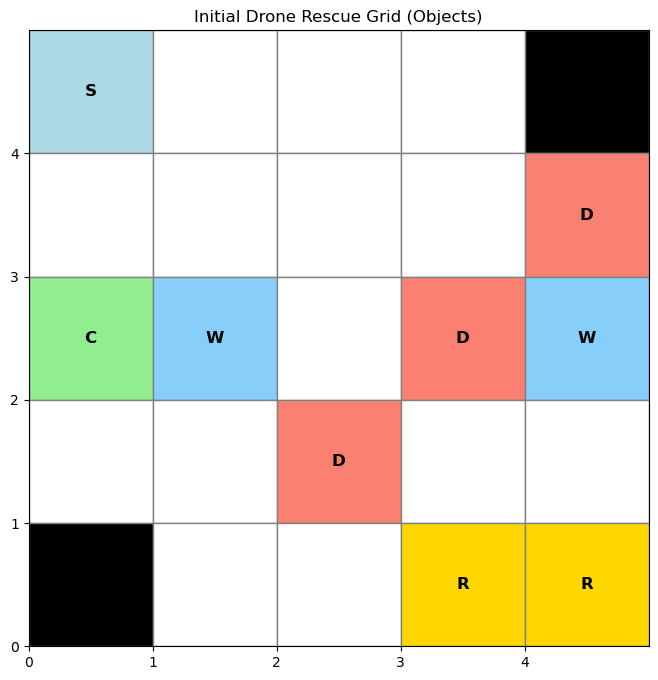

In [139]:
env = DroneRescueEnv()
env.render(title="Initial Drone Rescue Grid (Objects)")

In [140]:
def transition(env, state, action):
    """
        Computes transition outcomes for a given state and action.
        Handles wind zone stochasticity, battery updates, rescue collection,
        charging, and danger penalties.
        Returns list of (probability, next_state, reward, done) tuples.
    """
    r, c, bat, remaining = state
    pos = (r,c)
    if bat <= 0:
        return [(1.0, state, 0, True)]

    def deterministic_next(a):
        new_bat = bat - 1
        new_pos = pos
        new_remaining = list(remaining)
        rew = REWARDS['step']

        if a == 4:  # Hover
            if pos in env.charging_positions:
                new_bat = min(MAX_BATTERY, bat + 2)
                # No charging_arrival reward for hovering
                # that reward is only for arriving (moving onto it)
        else:
            dr, dc = ACTIONS[a]
            nr, nc = r + dr, c + dc
            new_pos = (nr, nc)
            if new_pos in env.blocked_positions or not (0 <= nr < GRID_SIZE and 0 <= nc < GRID_SIZE):
                new_pos = pos

        # charging_arrival reward only when MOVING onto station (not hovering)
        if a != 4 and new_pos in env.charging_positions and new_pos != pos:
            new_bat = MAX_BATTERY
            if bat < MAX_BATTERY:
                rew += REWARDS['charging_arrival']

        if new_pos in remaining:
            idx = remaining.index(new_pos)
            new_remaining.pop(idx)
            rew += REWARDS['rescue']

        if new_pos in env.danger_positions:
            rew += REWARDS['danger']

        done = False
        if new_bat <= 0:
            rew += REWARDS['battery_exhaust']
            done = True
        if len(new_remaining) == 0:
            done = True

        new_remaining_t = tuple(new_remaining)
        if new_bat <= 0:
            new_state = (r, c, 0, remaining)
        else:
            new_state = (new_pos[0], new_pos[1], new_bat, new_remaining_t)
        return new_state, rew, done

    if pos in env.wind_positions:
        outcomes = []
        ns, rw, dn = deterministic_next(action)
        outcomes.append((1 - WIND_PROB, ns, rw, dn))
        for rand_a in range(4):
            ns, rw, dn = deterministic_next(rand_a)
            outcomes.append((WIND_PROB/4.0, ns, rw, dn))
        merged = {}
        for prob, ns, rw, dn in outcomes:
            key = (ns, dn)
            if key not in merged:
                merged[key] = (0.0, 0.0)
            p_old, r_old = merged[key]
            merged[key] = (p_old + prob, r_old + prob * rw)
        result = [(prob, ns, rew, dn) for (ns, dn), (prob, rew) in merged.items()]
        return result
    else:
        ns, rw, dn = deterministic_next(action)
        return [(1.0, ns, rw, dn)]

In [141]:
def get_reachable_states(env):
    """
        Performs BFS from the start state to find all reachable states.
        Returns list of all states the drone can possibly reach.
    """
    start_state = (START_POS[0], START_POS[1], MAX_BATTERY - 1, tuple(sorted(env.rescue_positions)))
    visited = set()
    queue = [start_state]
    while queue:
        s = queue.pop(0)
        if s in visited:
            continue
        visited.add(s)
        r,c,bat,remaining = s
        if bat <= 0 or len(remaining) == 0:
            continue
        for a in range(5):
            for prob, ns, _, _ in transition(env, s, a):
                if prob > 0 and ns not in visited:
                    queue.append(ns)
    return list(visited)

In [142]:
def value_iteration(env, gamma=0.9, theta=1e-3):
    """
        Runs value iteration until convergence (delta < theta).
        Computes optimal value function V* and optimal policy pi*.
        Returns V, policy, state index mapping and convergence history.
    """
    states = get_reachable_states(env)
    print(f"Number of reachable states: {len(states)}")
    state_to_idx = {s: i for i, s in enumerate(states)}
    V = np.zeros(len(states))

    iter_count = 0
    delta_hist = []
    start_time = time.time()

    while True:
        delta = 0
        for s in states:
            r,c,bat,remaining = s
            if bat == 0 or len(remaining) == 0:
                continue
            idx = state_to_idx[s]
            q_vals = []
            for a in range(5):
                q = 0
                for prob, ns, rew, _ in transition(env, s, a):
                    nidx = state_to_idx.get(ns)
                    if nidx is None:
                        continue
                    q += prob * (rew + gamma * V[nidx])
                q_vals.append(q)
            best_q = max(q_vals)
            delta = max(delta, abs(best_q - V[idx]))
            V[idx] = best_q
        iter_count += 1
        delta_hist.append(delta)
        if delta < theta:
            break
        if iter_count > 5000:
            print("Max iterations reached")
            break

    elapsed = time.time() - start_time
    print(f"Value Iteration converged in {iter_count} iterations, final Δ={delta:.6f}, time={elapsed:.2f}s")

    policy = {}
    for s in states:
        r,c,bat,remaining = s
        if bat == 0 or len(remaining) == 0:
            V[idx] = 0
            continue
        idx = state_to_idx[s]
        best_a = None
        best_q = -np.inf
        for a in range(5):
            q = 0
            for prob, ns, rew, _ in transition(env, s, a):
                nidx = state_to_idx.get(ns)
                if nidx is None:
                    continue
                q += prob * (rew + gamma * V[nidx])
            if q > best_q:
                best_q = q
                best_a = a
        policy[s] = best_a
    return V, policy, state_to_idx, delta_hist

V_opt, policy_opt, state_idx, delta_hist = value_iteration(env, gamma=0.9, theta=1e-3)

Number of reachable states: 869
Value Iteration converged in 40 iterations, final Δ=0.000964, time=0.48s


Optimal first action from start: D


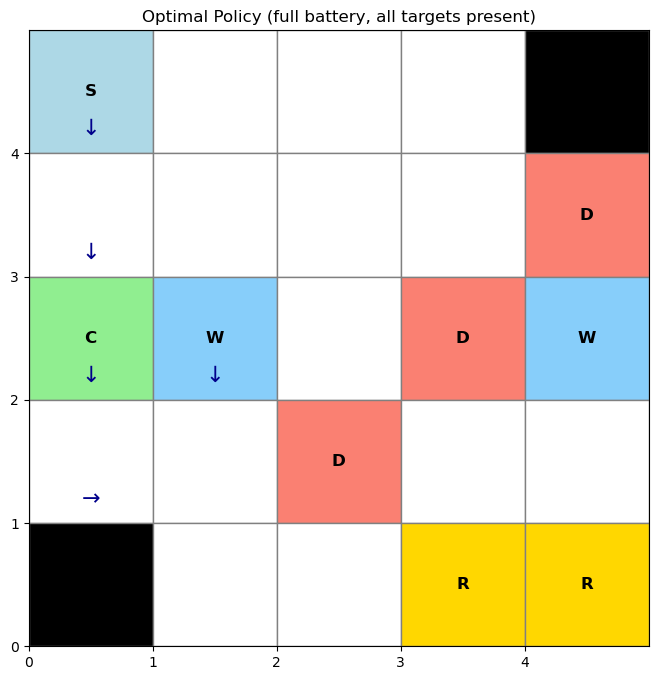

In [143]:
init_remaining = tuple(sorted(env.rescue_positions))
policy_map = {}
for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        pos = (r,c)
        if pos in env.blocked_positions:
            continue
        s = (r,c,MAX_BATTERY - 1,init_remaining)
        if s in policy_opt:
            policy_map[pos] = policy_opt[s]

start_state = (START_POS[0], START_POS[1], MAX_BATTERY - 1, init_remaining)
if start_state in policy_opt:
    print(f"Optimal first action from start: {ACTION_NAMES[policy_opt[start_state]]}")

env.render(policy_slice=policy_map, title="Optimal Policy (full battery, all targets present)")

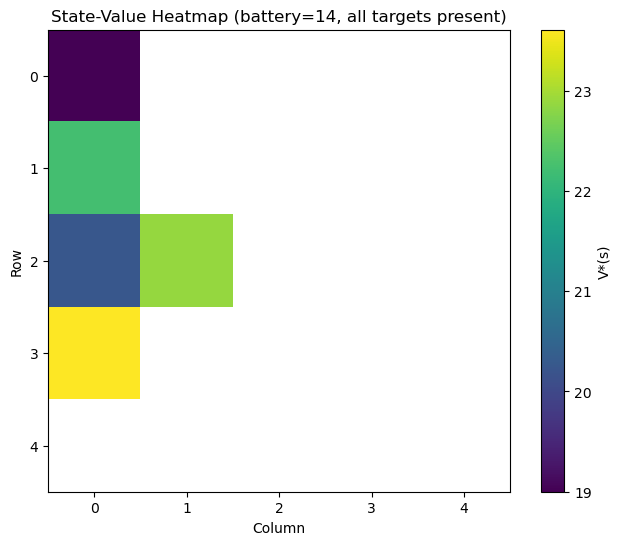

In [144]:
value_grid = np.full((GRID_SIZE, GRID_SIZE), np.nan)
for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        pos = (r,c)
        if pos in env.blocked_positions:
            continue
        s = (r,c,MAX_BATTERY - 1,init_remaining)
        idx = state_idx.get(s)
        if idx is not None:
            value_grid[r,c] = V_opt[idx]

plt.figure(figsize=(8,6))
im = plt.imshow(value_grid, origin='upper', cmap='viridis', interpolation='nearest')
plt.colorbar(im, label='V*(s)')
plt.title(f'State-Value Heatmap (battery={MAX_BATTERY - 1}, all targets present)')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

In [145]:
def simulate_optimal(env, policy):
    """
        Simulates drone following the optimal policy step by step.
        Tracks rescue order, total reward and steps taken.
    """
    state = env.reset()
    total_reward = 0
    steps = 0
    rescue_order = []
    print("Starting simulation with optimal policy...")
    while not env.done:
        action = policy.get(state, 4)
        targets_before = set(state[3])
        next_state, reward, done, _ = env.step(action)
        total_reward += reward
        steps += 1
        state = next_state
        targets_after = set(state[3])
        newly_rescued = targets_before - targets_after
        if newly_rescued:
            rescue_order.append(newly_rescued.pop())
        if done:
            break
    print(f"Rescue order (positions): {rescue_order}")
    print(f"Steps taken: {steps}, Total reward: {total_reward}")
    return rescue_order

env.reset()
rescue_seq = simulate_optimal(env, policy_opt)

Starting simulation with optimal policy...
Rescue order (positions): [(4, 3), (4, 4)]
Steps taken: 8, Total reward: 37


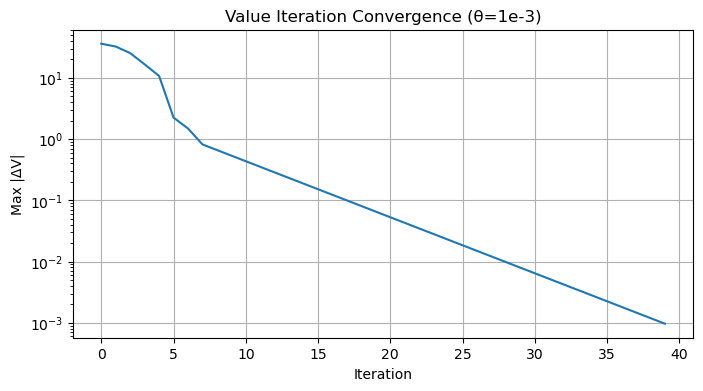

In [146]:
plt.figure(figsize=(8,4))
plt.semilogy(delta_hist)
plt.xlabel('Iteration')
plt.ylabel('Max |ΔV|')
plt.title('Value Iteration Convergence (θ=1e-3)')
plt.grid(True)
plt.show()

## Scalability Discussion

### Curse of Dimensionality
The state space of this drone MDP grows as:
- **Positions**: O(grid cells)
- **Battery**: O(max battery level)
- **Rescue targets**: O(2^(#targets))

For a 10×10 grid, 15 battery, 5 targets → 100 × 16 × 32 = 51,200 states. Still manageable for DP. However, adding 10 targets → 100 × 16 × 1024 = 1.6 million states, which is large but still possible with efficient coding.

### Impact of larger grid (10×10)
State count increases by factor 4, DP still feasible but runtime grows linearly. Memory might become an issue if we store full transition matrices.

### Additional rescue targets
Exponential growth in the number of subsets (2^n). With n > 15, explicit enumeration becomes impossible.

### Dynamic weather (wind probability changes over time)
This would add another dimension: time or weather state. If wind has k possible patterns, state size multiplies by k. DP quickly becomes infeasible.

### Why DP becomes difficult
- State space explosion (combinatorial)
- Need to know full transition probabilities a priori
- Cannot handle continuous or very large discrete variables
- Each iteration requires sweeping all states

### How Deep RL helps
- Function approximation (neural networks) generalises across states without enumeration
- Can handle high-dimensional inputs (e.g., raw sensor data)
- Works with continuous state spaces (battery level, position coordinates)
- Sample-based learning avoids explicit transition model

### Real-world Autonomous Drone Systems

Real rescue drones operate in large, uncertain environments with changing weather,
dynamic obstacles, incomplete information, and limited communication. Enumerating
all states (position, battery, rescue status, wind conditions, time of day, etc.)
becomes impossible. Dynamic Programming is therefore not feasible for real‑world
deployment. Deep Reinforcement Learning overcomes this limitation by using
function approximation (neural networks) that generalise across states and can
handle high‑dimensional inputs such as camera images or LIDAR data. Moreover,
deep RL can learn directly from experience without requiring an explicit model
of the environment, making it much more suitable for autonomous drone systems
in disaster zones.